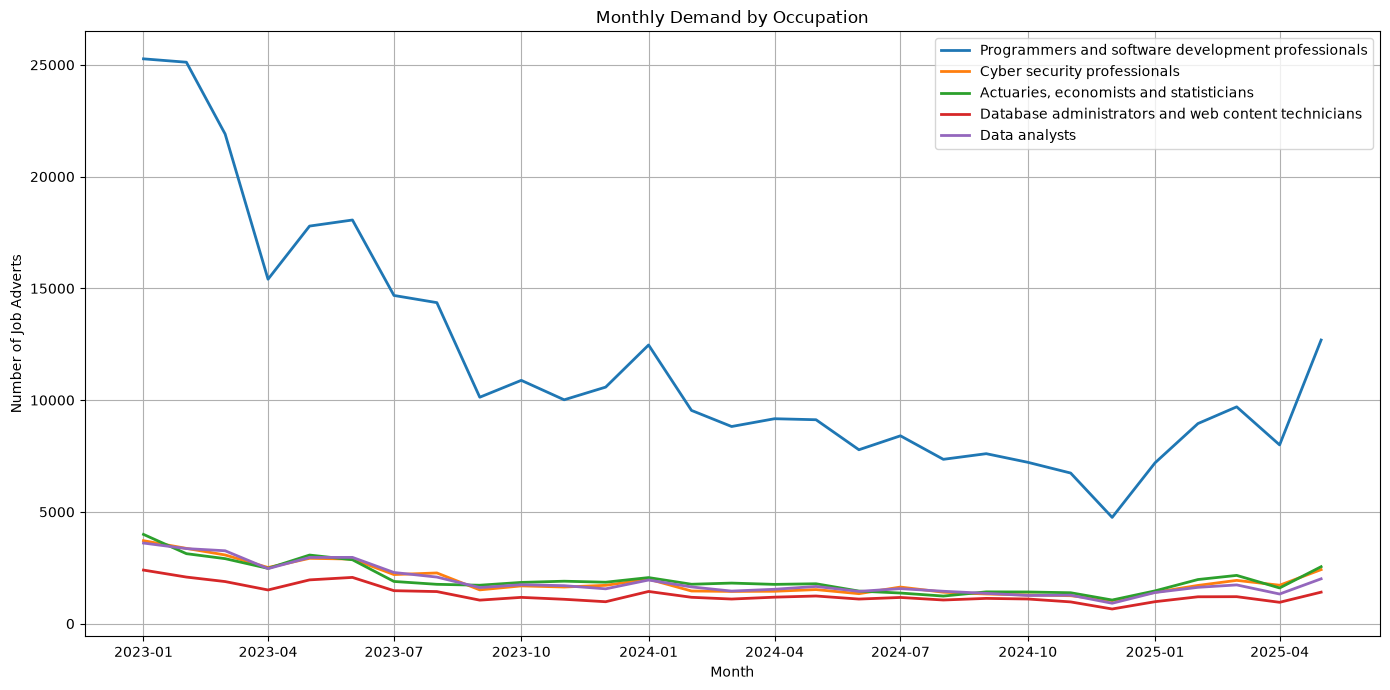

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

master_df = pd.read_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\master_dataset.csv"
)

master_df["Month"] = pd.to_datetime(master_df["Month"])

plt.figure(figsize=(14,7))

for occupation in master_df["Occupation"].unique():
    temp = master_df[master_df["Occupation"] == occupation]

    plt.plot(
        temp["Month"],
        temp["Demand"],
        linewidth=2,
        label=occupation
    )

plt.title("Monthly Demand by Occupation")
plt.xlabel("Month")
plt.ylabel("Number of Job Adverts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
plt.savefig(
    r"D:\MScProjects\labour-market-intelligence\results\demand_trend_by_occupation.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

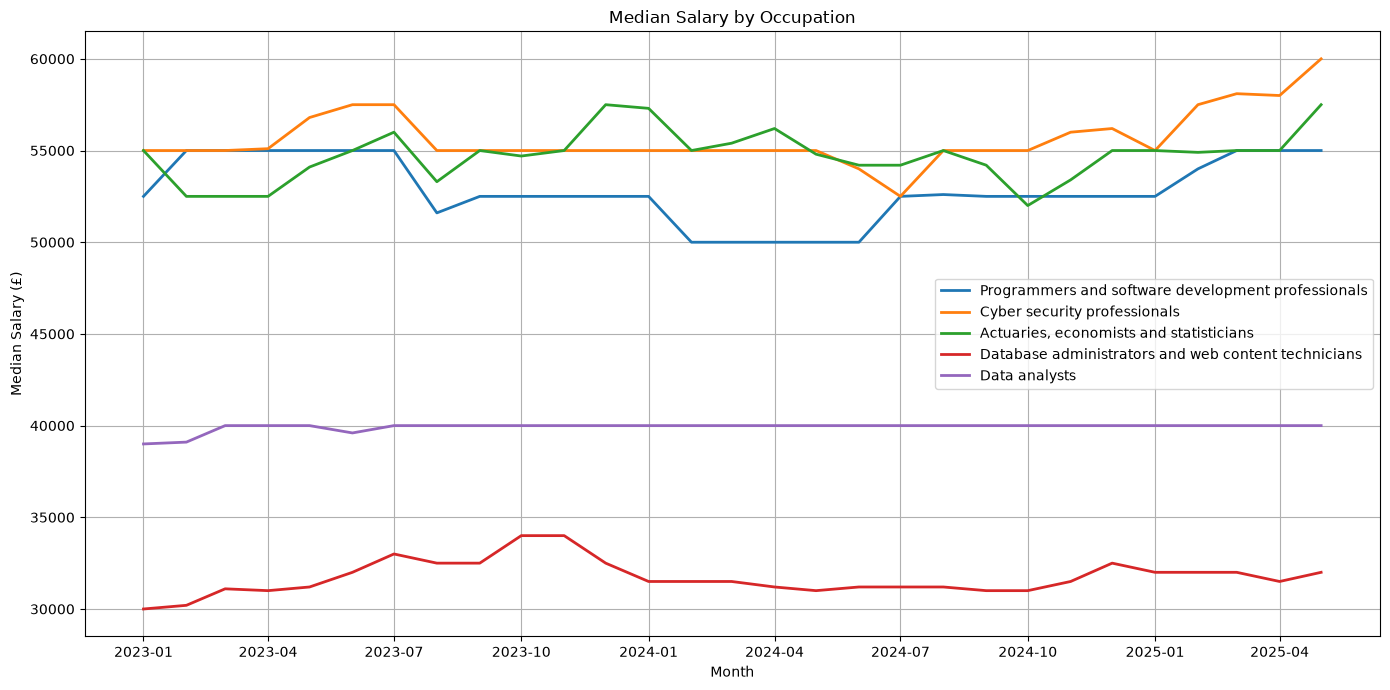

In [3]:
plt.figure(figsize=(14,7))

for occupation in master_df["Occupation"].unique():
    temp = master_df[master_df["Occupation"] == occupation]

    plt.plot(
        temp["Month"],
        temp["Median_Salary"],
        linewidth=2,
        label=occupation
    )

plt.title("Median Salary by Occupation")
plt.xlabel("Month")
plt.ylabel("Median Salary (£)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
plt.savefig(
    r"D:\MScProjects\labour-market-intelligence\results\salary_trend_by_occupation.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [6]:
occupation_summary = (
    master_df
    .groupby("Occupation")
    .agg(
        Average_Demand=("Demand", "mean"),
        Average_Salary=("Median_Salary", "mean")
    )
    .reset_index()
)

occupation_summary


,Occupation,Average_Demand,Average_Salary
0,"Actuaries, economists and statisticians",1988.379310,54731.034483
1,Cyber security professionals,1924.827586,55662.068966
2,Data analysts,1903.413793,39920.689655
3,Database administrators and web content techni...,1317.137931,31717.241379
4,Programmers and software development professio...,11714.068966,52868.965517


In [7]:
occupation_summary.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\occupation_summary_dashboard.csv",
    index=False
)

In [8]:
master_df.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\powerbi_master.csv",
    index=False
)